In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from collections import defaultdict

ROOT = Path("..").resolve()
print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: /home/diego/arxiv_classifier


## Sección 1 — Del corpus al dataset

El corpus de partida son 2000 papers de arXiv distribuidos en 10 categorías de ciencias de la computación. De cada paper se extrajeron los abstracts de tres formas distintas:

- **`abstract_api`** — obtenido directamente de la API de arXiv. Es la fuente más confiable porque proviene de los metadatos oficiales del paper, siempre está disponible y no depende de la calidad del PDF.
- **`abstract_pymupdf`** — extraído del PDF usando PyMuPDF. Puede contener ruido tipográfico (guiones de separación de sílabas, caracteres especiales) o estar incompleto si el PDF tiene un layout no estándar.
- **`abstract_docling`** — extraído del PDF usando Docling (modelo basado en visión). Más robusto ante layouts complejos, pero más lento y ocasionalmente introduce artefactos de reconocimiento.

**Decisión clave:** los tres abstracts se almacenan en el **mismo registro**. Esto permite entrenar tres modelos independientes usando la misma partición de datos (mismo train/val/test) y comparar directamente el impacto de la fuente del texto sobre la calidad de clasificación.

**Qué se descarta:** ningún artículo se elimina del dataset por tener una extracción fallida. Un abstract vacío en pymupdf o docling simplemente significa que ese artículo no participará en el experimento de esa fuente. Esto se filtra al momento de entrenar, no aquí.

In [7]:
# Cargamos extracted.json, que contiene todos los campos de extracción
# antes de renombrar y limpiar campos para el dataset final.
with open(ROOT / "data/interim/extracted.json") as f:
    extracted = json.load(f)

print(f"Total de registros en extracted.json: {len(extracted)}")
print(f"Campos disponibles: {list(extracted[0].keys())}")
print()

# Mostramos un registro completo para entender la estructura raw
sample = extracted[0]
for key, value in sample.items():
    if isinstance(value, str) and len(value) > 120:
        print(f"{key}: {value[:120]}...")
    else:
        print(f"{key}: {value}")

Total de registros en extracted.json: 2000
Campos disponibles: ['arxiv_id', 'category', 'title', 'abstract_api', 'abstract_pymupdf', 'abstract_docling', 'score_pymupdf', 'score_docling', 'extraction_status']

arxiv_id: 2605.12481
category: cs.AI
title: ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents
abstract_api: Computer Use Agents (CUAs) can act through both atomic GUI actions, such as click and type, and high-level tool calls, s...
abstract_pymupdf: ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents Xuhao, Hu2,1,∗, Xi Zhang1,∗, Haiyang Xu1,†,...
abstract_docling: ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents Xuhao, Hu 2,1, ∗ , Xi Zhang 1, ∗ , Haiyang ...
score_pymupdf: 0.8418722152709961
score_docling: 0.8402345180511475
extraction_status: {'pymupdf': 'ok', 'docling': 'ok'}


In [8]:
# Verificamos la disponibilidad real de cada fuente de abstract.
# Un abstract se considera válido si no está vacío después de strip().
total = len(extracted)

def count_valid(data, field):
    return sum(1 for r in data if r.get(field, "").strip() != "")

valid_api     = count_valid(extracted, "abstract_api")
valid_pymupdf = count_valid(extracted, "abstract_pymupdf")
valid_docling = count_valid(extracted, "abstract_docling")

print(f"{'Fuente':<20} {'Válidos':>8} {'Vacíos':>8} {'% válido':>10}")
print("-" * 50)
for name, valid in [("abstract_api", valid_api), ("abstract_pymupdf", valid_pymupdf), ("abstract_docling", valid_docling)]:
    empty = total - valid
    pct   = 100 * valid / total
    print(f"{name:<20} {valid:>8} {empty:>8} {pct:>9.1f}%")

Fuente                Válidos   Vacíos   % válido
--------------------------------------------------
abstract_api             2000        0     100.0%
abstract_pymupdf         2000        0     100.0%
abstract_docling         1995        5      99.8%


## Sección 2 — Estructura del dataset final

`data/processed/dataset.json` es el archivo limpio derivado de `extracted.json`. Contiene los mismos 2000 artículos pero con la estructura normalizada para el pipeline de entrenamiento:

| Campo | Descripción |
|---|---|
| `arxiv_id` | Identificador único del paper en arXiv |
| `title` | Título del paper |
| `label` | Categoría de arXiv (ej. `cs.LG`) |
| `label_id` | Índice numérico de la clase (0–9) |
| `abstract_api` | Abstract obtenido de la API de arXiv |
| `abstract_pymupdf` | Abstract extraído del PDF con PyMuPDF |
| `abstract_docling` | Abstract extraído del PDF con Docling |
| `score_pymupdf` | Puntuación de confianza de la extracción PyMuPDF |
| `score_docling` | Puntuación de confianza de la extracción Docling |
| `extraction_status` | Estado de cada extracción (`ok` / `failed` / etc.) |

Los campos `score_*` y `extraction_status` son trazabilidad de calidad: permiten entender si un abstract vacío fue fallo del extractor o ausencia del campo.

In [9]:
# Cargamos dataset.json y mostramos 2 registros completos
# para verificar la estructura normalizada.
with open(ROOT / "data/processed/dataset.json") as f:
    dataset = json.load(f)

print(f"Total registros: {len(dataset)}")
print(f"Campos: {list(dataset[0].keys())}")
print()

for i, record in enumerate(dataset[:2]):
    print(f"=== Registro {i} ===")
    for key, value in record.items():
        if isinstance(value, str) and len(value) > 100:
            print(f"  {key}: {value[:100]}...")
        else:
            print(f"  {key}: {value}")
    print()

Total registros: 2000
Campos: ['arxiv_id', 'title', 'label', 'label_id', 'abstract_api', 'abstract_pymupdf', 'abstract_docling', 'score_pymupdf', 'score_docling', 'extraction_status']

=== Registro 0 ===
  arxiv_id: 2605.12481
  title: ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents
  label: cs.AI
  label_id: 0
  abstract_api: Computer Use Agents (CUAs) can act through both atomic GUI actions, such as click and type, and high...
  abstract_pymupdf: ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents Xuhao, Hu2,1,∗, Xi Zhan...
  abstract_docling: ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents Xuhao, Hu 2,1, ∗ , Xi Z...
  score_pymupdf: 0.8418722152709961
  score_docling: 0.8402345180511475
  extraction_status: {'pymupdf': 'ok', 'docling': 'ok'}

=== Registro 1 ===
  arxiv_id: 2605.12474
  title: Reward Hacking in Rubric-Based Reinforcement Learning
  label: cs.AI
  label_id: 0
  abstract_api: Reinforceme

In [10]:
# El label_map define la correspondencia entre categoría de arXiv y el índice
# numérico que usará el modelo. El orden es fijo y se guarda en configs/
# para que entrenamiento y evaluación usen exactamente el mismo mapeo.
with open(ROOT / "configs/label_map.json") as f:
    label_map = json.load(f)

print(f"Clases ({len(label_map)} en total):")
print()
print(f"{'Label':<10} {'label_id':>8}")
print("-" * 22)
for label, lid in sorted(label_map.items(), key=lambda x: x[1]):
    print(f"{label:<10} {lid:>8}")

Clases (10 en total):

Label      label_id
----------------------
cs.AI             0
cs.CL             1
cs.CR             2
cs.CV             3
cs.DB             4
cs.IR             5
cs.LG             6
cs.NE             7
cs.RO             8
cs.SE             9


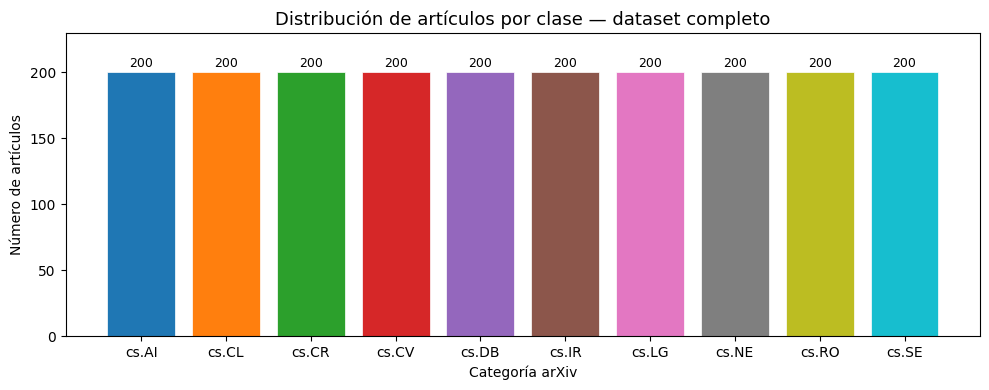

In [11]:
# Distribución de artículos por clase en el dataset completo.
# Con un split estratificado esperamos proporciones similares en train/val/test.
label_counts = defaultdict(int)
for record in dataset:
    label_counts[record["label"]] += 1

labels_sorted = sorted(label_counts.keys())
counts = [label_counts[l] for l in labels_sorted]

# Colores distintos por barra para facilitar la lectura
colors = cm.tab10(np.linspace(0, 1, len(labels_sorted)))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels_sorted, counts, color=colors, edgecolor="white", linewidth=0.5)

# Etiqueta de conteo sobre cada barra
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(count),
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Distribución de artículos por clase — dataset completo", fontsize=13)
ax.set_xlabel("Categoría arXiv")
ax.set_ylabel("Número de artículos")
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

## Sección 3 — Análisis de los textos

Antes de entrenar, conviene entender la distribución de longitudes de los abstracts. Esto importa por dos razones:

- **Abstracts muy cortos** (< 30 palabras) suelen ser extracciones fallidas: el extractor capturó una línea del header del PDF en lugar del abstract real. Podría contaminar el entrenamiento.
- **Abstracts muy largos** (> 400 palabras) pueden incluir texto que no es el abstract: introducción, notas de pie de página o contenido de otras secciones del PDF. SciBERT trunca a 512 tokens (≈ 380 palabras), así que el exceso se descarta.

Comparar las tres fuentes permite detectar si alguna extracción introduce sesgos sistemáticos de longitud.

In [12]:
# Longitud en palabras de abstract_api agrupada por clase.
# Usamos abstract_api como referencia por ser la fuente más limpia.
lengths_by_class = defaultdict(list)
for record in dataset:
    text = record.get("abstract_api", "").strip()
    if text:
        lengths_by_class[record["label"]].append(len(text.split()))

print(f"{'Clase':<8} {'Promedio':>10} {'Mediana':>10} {'Mín':>6} {'Máx':>6}")
print("-" * 44)
for label in sorted(lengths_by_class.keys()):
    lens = lengths_by_class[label]
    print(
        f"{label:<8}"
        f"{np.mean(lens):>10.1f}"
        f"{np.median(lens):>10.1f}"
        f"{min(lens):>6}"
        f"{max(lens):>6}"
    )

Clase      Promedio    Mediana    Mín    Máx
--------------------------------------------
cs.AI        191.4     194.0    86   278
cs.CL        179.8     177.5    61   274
cs.CR        194.3     198.0    81   306
cs.CV        187.4     188.0   104   272
cs.DB        187.8     193.0    51   287
cs.IR        193.9     193.0    97   280
cs.LG        182.7     183.0    58   288
cs.NE        179.8     181.0    75   266
cs.RO        180.2     181.0    39   274
cs.SE        195.8     203.5    22   292


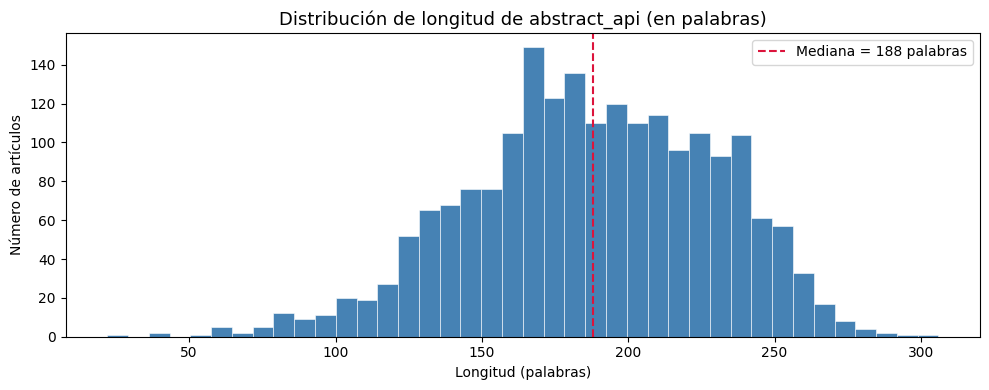

In [13]:
# Histograma global de longitud de abstract_api.
# La línea vertical marca la mediana: referencia práctica para entender
# dónde cae la mayoría de los textos respecto al límite de SciBERT (~380 palabras).
all_lengths = [
    len(r["abstract_api"].split())
    for r in dataset
    if r.get("abstract_api", "").strip()
]
median_len = np.median(all_lengths)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_lengths, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(median_len, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Mediana = {median_len:.0f} palabras")
ax.set_title("Distribución de longitud de abstract_api (en palabras)", fontsize=13)
ax.set_xlabel("Longitud (palabras)")
ax.set_ylabel("Número de artículos")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Comparación de las tres fuentes: promedio de palabras, mediana y % de vacíos.
# Un % de vacíos alto indica que esa fuente tiene baja cobertura
# y el modelo entrenado con ella usará menos artículos.
sources = ["abstract_api", "abstract_pymupdf", "abstract_docling"]

print(f"{'Fuente':<22} {'Promedio':>10} {'Mediana':>10} {'% vacíos':>10}")
print("-" * 56)

for source in sources:
    lens   = [len(r[source].split()) for r in dataset if r.get(source, "").strip()]
    empty  = sum(1 for r in dataset if not r.get(source, "").strip())
    pct_empty = 100 * empty / len(dataset)
    print(
        f"{source:<22}"
        f"{np.mean(lens):>10.1f}"
        f"{np.median(lens):>10.1f}"
        f"{pct_empty:>9.1f}%"
    )

Fuente                   Promedio    Mediana   % vacíos
--------------------------------------------------------
abstract_api               187.3     188.0      0.0%
abstract_pymupdf           203.4     195.0      0.0%
abstract_docling           215.3     200.0      0.2%


## Sección 4 — Los tres splits

El dataset se divide en **train / val / test** con proporciones 75 / 12.5 / 12.5 usando un **stratified split**: cada clase tiene la misma proporción en los tres conjuntos.

¿Por qué importa el balance?
- Si una clase aparece solo en train y no en val, el modelo nunca recibe señal de validación para esa clase → no podemos seleccionar el mejor checkpoint de forma fiable.
- Si una clase no aparece en test, la métrica de evaluación final para esa clase será 0 sin reflejar el rendimiento real.

El split se fija con una semilla aleatoria (`random_state=42`) para que sea reproducible.

In [15]:
# Distribución de clases en cada split.
# Si el stratified split funcionó correctamente, los porcentajes deben
# ser aproximadamente iguales en las tres columnas para cada clase.
with open(ROOT / "data/processed/train.json") as f:
    train_data = json.load(f)
with open(ROOT / "data/processed/val.json") as f:
    val_data = json.load(f)
with open(ROOT / "data/processed/test.json") as f:
    test_data = json.load(f)

def class_counts(data):
    counts = defaultdict(int)
    for r in data:
        counts[r["label"]] += 1
    return counts

train_counts = class_counts(train_data)
val_counts   = class_counts(val_data)
test_counts  = class_counts(test_data)

all_labels = sorted(label_map.keys())

print(f"{'Clase':<8} {'Train':>7} {'Val':>7} {'Test':>7}   {'Train%':>7} {'Val%':>7} {'Test%':>7}")
print("-" * 60)
for label in all_labels:
    tr = train_counts[label]
    va = val_counts[label]
    te = test_counts[label]
    total_label = tr + va + te
    print(
        f"{label:<8}"
        f"{tr:>7} {va:>7} {te:>7}"
        f"   {100*tr/total_label:>6.1f}% {100*va/total_label:>6.1f}% {100*te/total_label:>6.1f}%"
    )
print("-" * 60)
print(
    f"{'TOTAL':<8}"
    f"{len(train_data):>7} {len(val_data):>7} {len(test_data):>7}"
)

Clase      Train     Val    Test    Train%    Val%   Test%
------------------------------------------------------------
cs.AI       140      30      30     70.0%   15.0%   15.0%
cs.CL       140      30      30     70.0%   15.0%   15.0%
cs.CR       140      30      30     70.0%   15.0%   15.0%
cs.CV       140      30      30     70.0%   15.0%   15.0%
cs.DB       140      30      30     70.0%   15.0%   15.0%
cs.IR       140      30      30     70.0%   15.0%   15.0%
cs.LG       140      30      30     70.0%   15.0%   15.0%
cs.NE       140      30      30     70.0%   15.0%   15.0%
cs.RO       140      30      30     70.0%   15.0%   15.0%
cs.SE       140      30      30     70.0%   15.0%   15.0%
------------------------------------------------------------
TOTAL      1400     300     300


In [16]:
# Verificación de integridad: ninguna clase debe tener 0 artículos
# en ninguno de los tres splits. Si el stratified split fue correcto, 
# esta celda no debe imprimir ninguna advertencia.
ok = True
for split_name, split_counts in [("train", train_counts), ("val", val_counts), ("test", test_counts)]:
    for label in all_labels:
        if split_counts[label] == 0:
            print(f"ADVERTENCIA: clase '{label}' tiene 0 artículos en {split_name}")
            ok = False

if ok:
    print("OK: todas las clases tienen al menos un artículo en train, val y test.")

OK: todas las clases tienen al menos un artículo en train, val y test.


## Sección 5 — Punto clave

Las decisiones tomadas en esta etapa determinan la validez de la comparación entre modelos:

**Dataset unificado con 3 fuentes**  
Almacenar los tres abstracts en el mismo registro garantiza que los modelos `scibert_api`, `scibert_pymupdf` y `scibert_docling` se entrenan y evalúan sobre **exactamente los mismos artículos** (salvo los filtrados por abstracto vacío). Cualquier diferencia en métricas se atribuye a la fuente del texto, no a diferencias en los datos.

**Balance de clases garantizado por stratified split**  
Con 200 artículos por clase y un split estratificado, cada clase aparece en proporciones estables en los tres conjuntos. Esto hace que las métricas de validación sean comparables entre epochs y entre fuentes.

**Los artículos con extracción fallida no se descartan del dataset**  
Un abstract vacío en pymupdf o docling no implica que el artículo sea inválido. Se descarta solo del experimento de esa fuente, en el momento de cargar los datos para entrenar (`load_splits()` en `train_bert.py`). El dataset permanece íntegro, lo que permite recalcular los splits o añadir una cuarta fuente sin modificar la partición existente.